## The fiducial model `fargo_fiducial`

| parameter | value |
| -------- | ------- |
| planet mass $M_p$| 5 Jupiter masses |
| viscosity $\alpha$ | $10^{-3}$|
| sigma slope | 1 |
|flang | 0.05|
| $r_0$ | 57au |
|$r_{in}$| 0.3 $r_0$ (ca. 20 au)|
|$r_{out}$ |7 $r_0$ (ca. 400 au)|
|AspectRatio at $r_0$  | 0.069|
|FlaringIndex  at $r_0$ | 0.2497|
| mstar| 1.08 solar masses|
|rstar| 1.418 $r_{sun}$|
|tstar| 4400K|


## Other models

For the other models, all parameters are chosen like in `fargo_fiducial`, except for one.

| model name  | altered parameter |
| -------- | ------- |
| fargo_high_mass  | $M_p$ = 10 Jupiter masses   |
| fargo_low_mass | $M_p$  = 2 Jupiter masses |
| fargo_high_visc | alpha = $10^{-2}$|
| fargo_low_visc | alpha = $10^{-4}$|
|fargo_sigslop_0 | sigmaslope = 0 |
|fargo_sigslop_0.5 | sigmaslope = 0.5 |
|fargo_sigslop_-2| sigmaslope = -2 |

# Loading and analyzing the model from Fargo3d

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

SMALL_SIZE = 15
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


In [41]:
path_start = f"/pfs/10/work/hd_cu284-work2/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen", "fargo_fiducial_companion" ]

titles = ["fiducial", "$M_p = 10 M_{jup}$", "$M_p = 2 M_{Jup}$", "$\\alpha = 10^{-2}$", "$\\alpha = 10^{-4}$", "$\\gamma = 0$",
          "$\\gamma = 0.5$", "$\\gamma = -2$", "$\\gamma = 1.5$"]

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [42]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

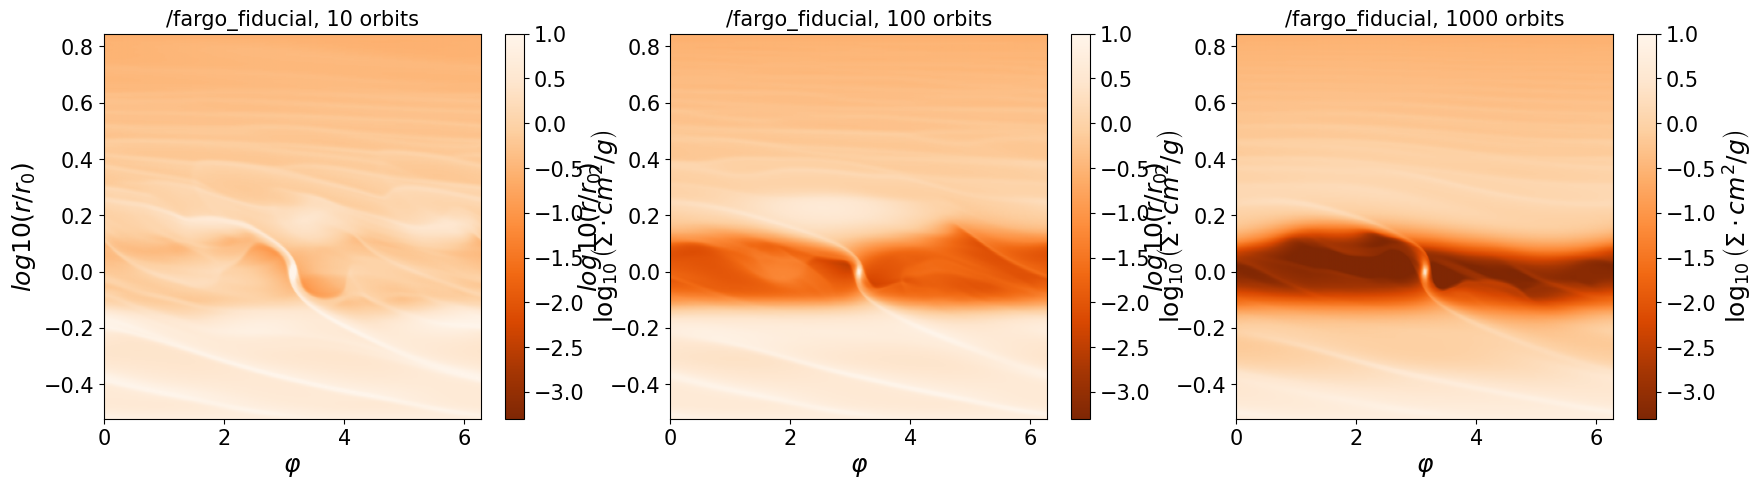

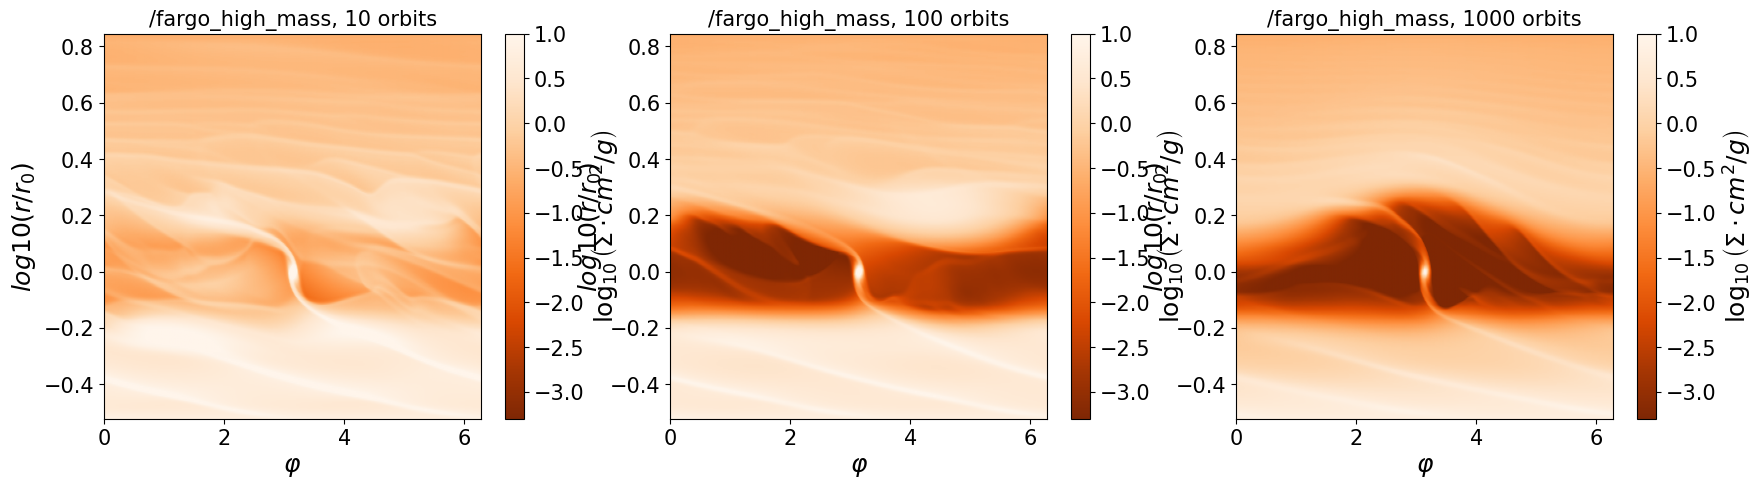

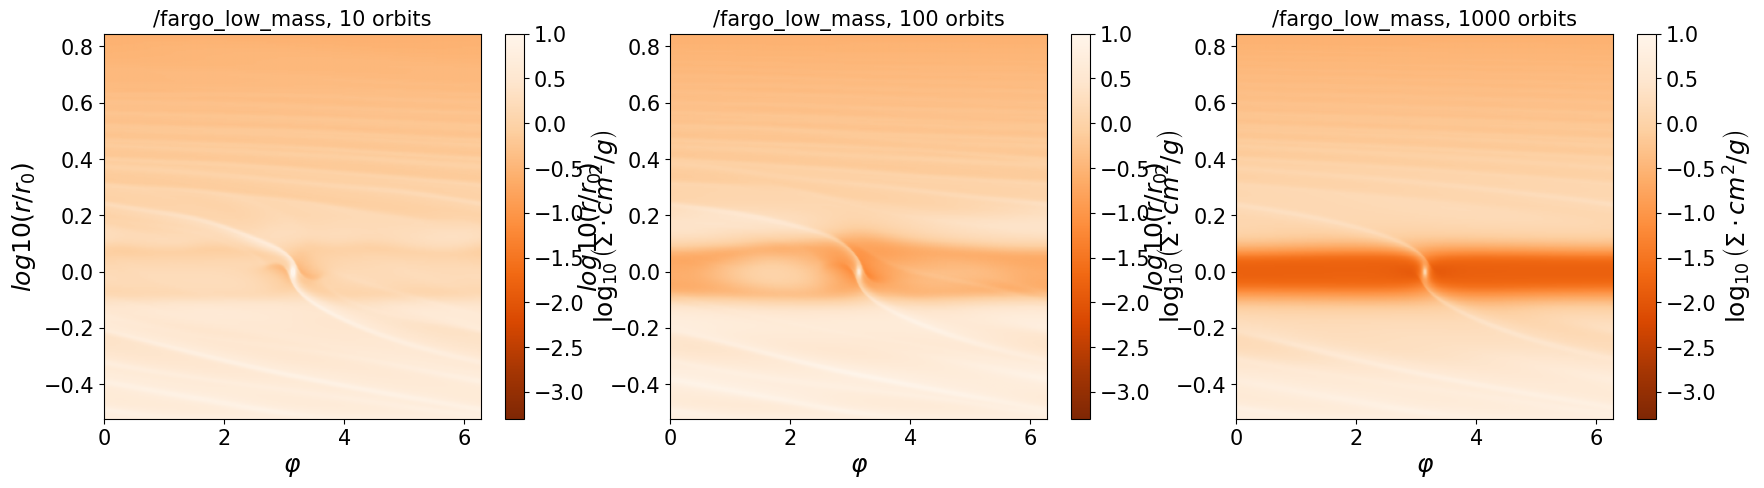

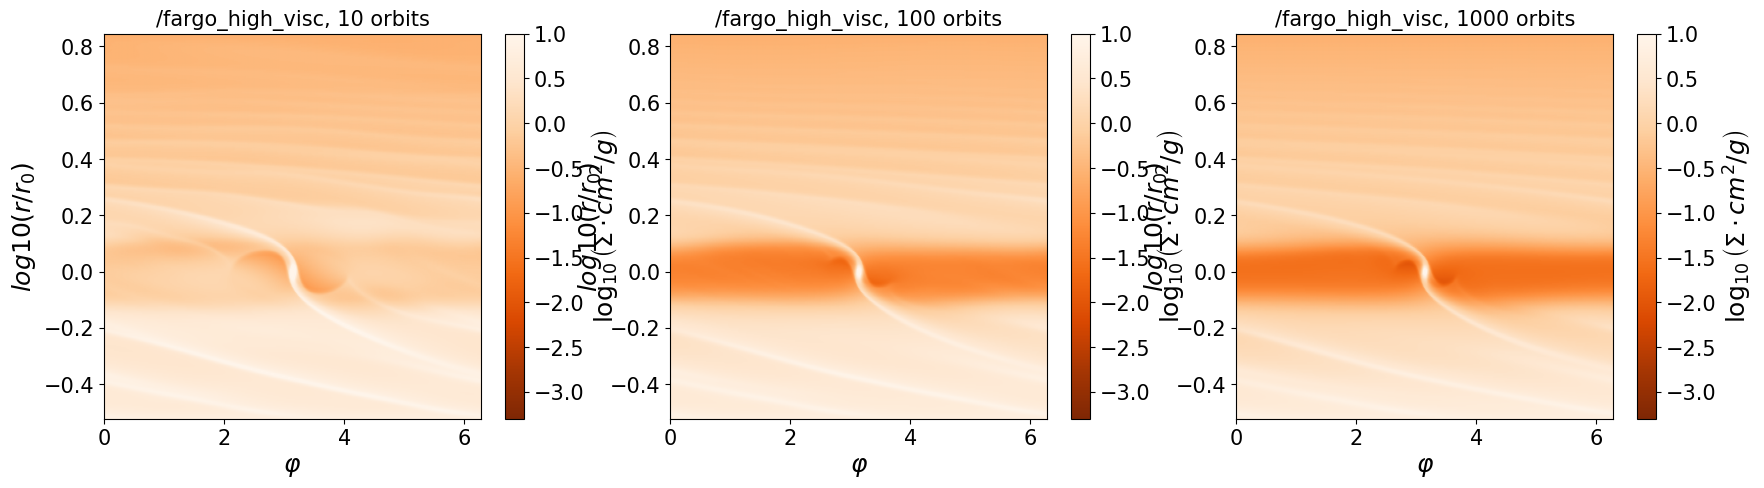

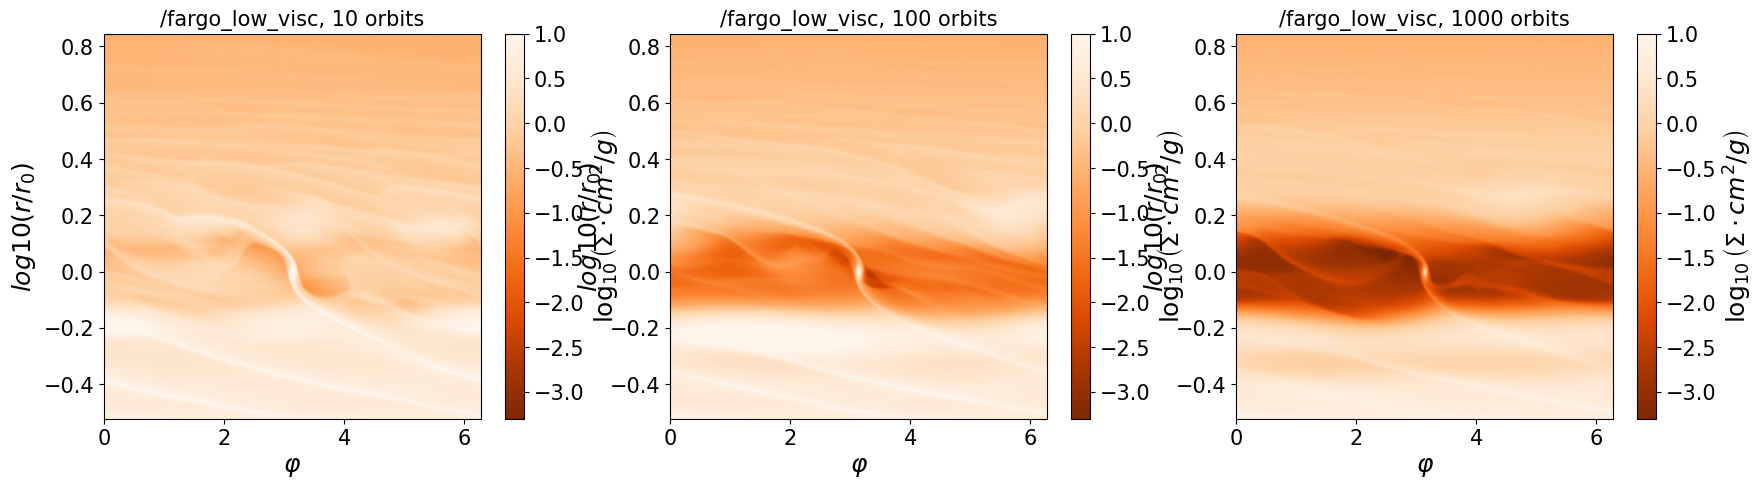

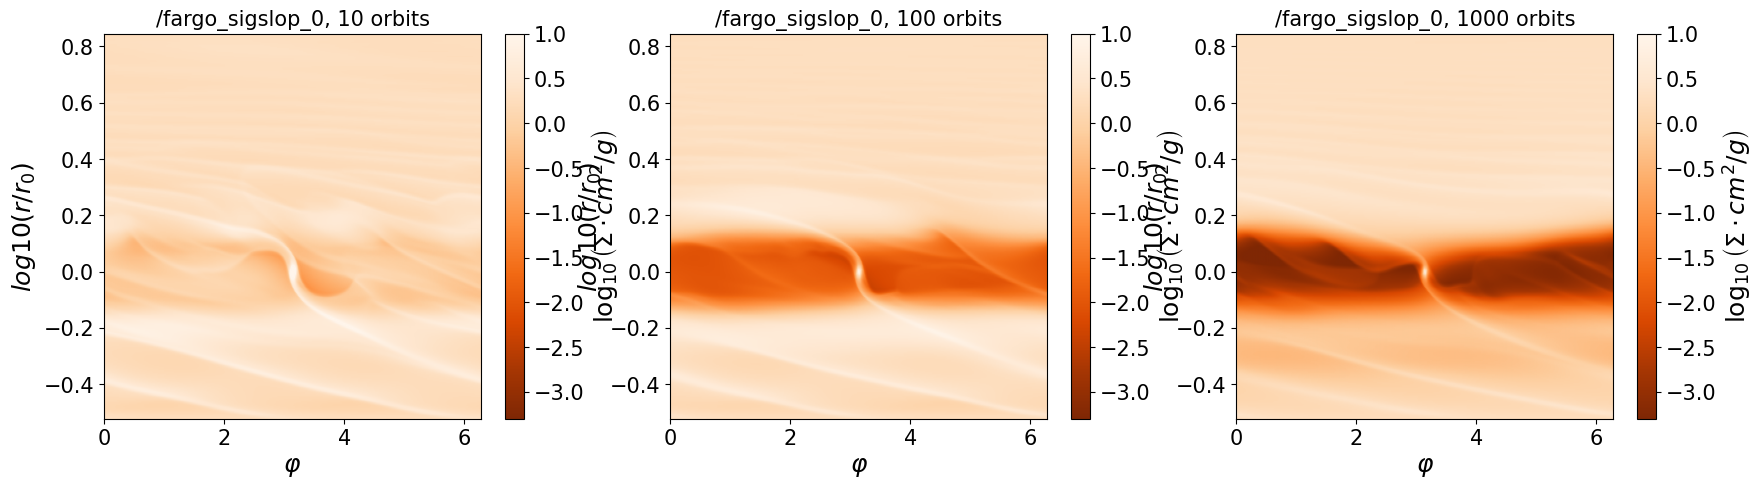

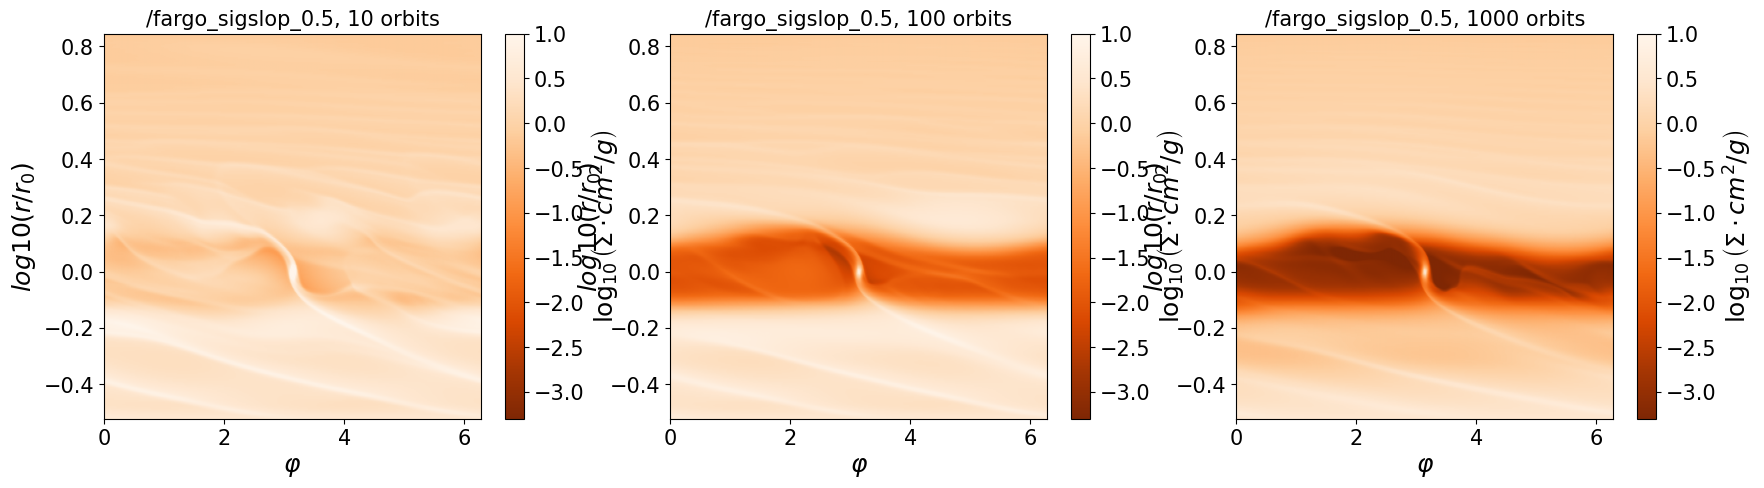

In [ ]:
%matplotlib inline
r_min = 0.3
r_max = 7

for i in range(len(paths[:])):
    plt.figure(figsize=(7*len(frames),5))
    path = paths[i]
    for it,frame in enumerate(frames[:]):
        if frame ==0:
            continue
        plt.subplot(1,len(frames),it+1)
        plt.imshow(np.log10(rho_cube[i][it]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)], clim = (1,-3))
        plt.title(f"{path[43:-5]}, {(frame)*10} orbits")
        plt.ylabel("$log10(r/r_0)$")
        plt.xlabel("$\\varphi$")
        plt.colorbar(label="$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$")


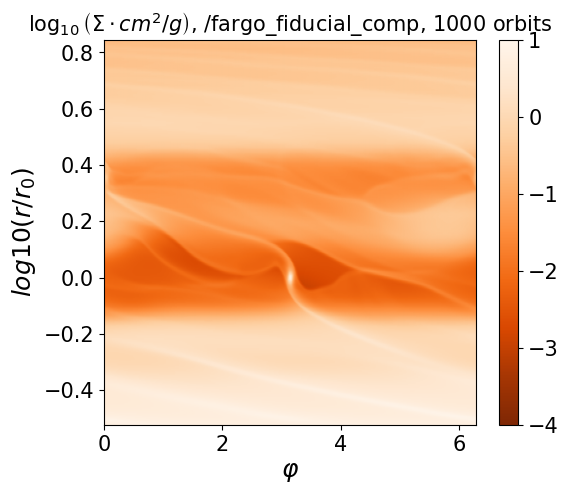

In [17]:
%matplotlib inline
r_min = 0.3
r_max = 7

for i in [-1]:#range(len(paths)):
    plt.figure(figsize=(6,5))
    path = paths[i]
    it = -1
    frame = frames[-1]
    plt.imshow(np.log10(rho_cube[i][it]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)], clim=(-4,1))
    plt.title(f"$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()
    plt.show()


In [18]:


Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

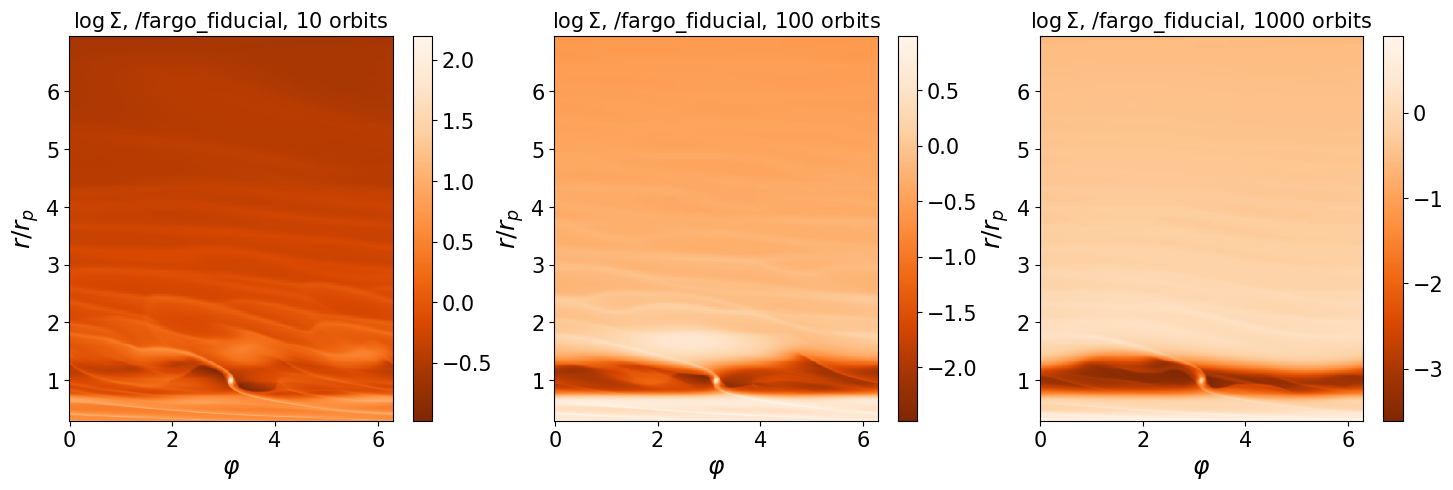

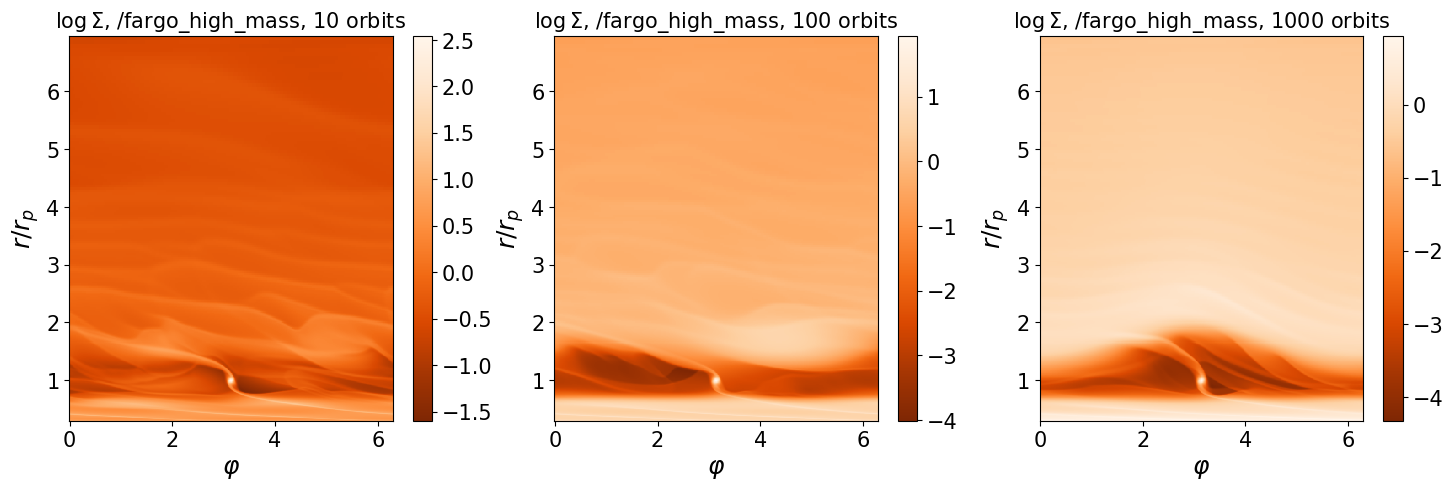

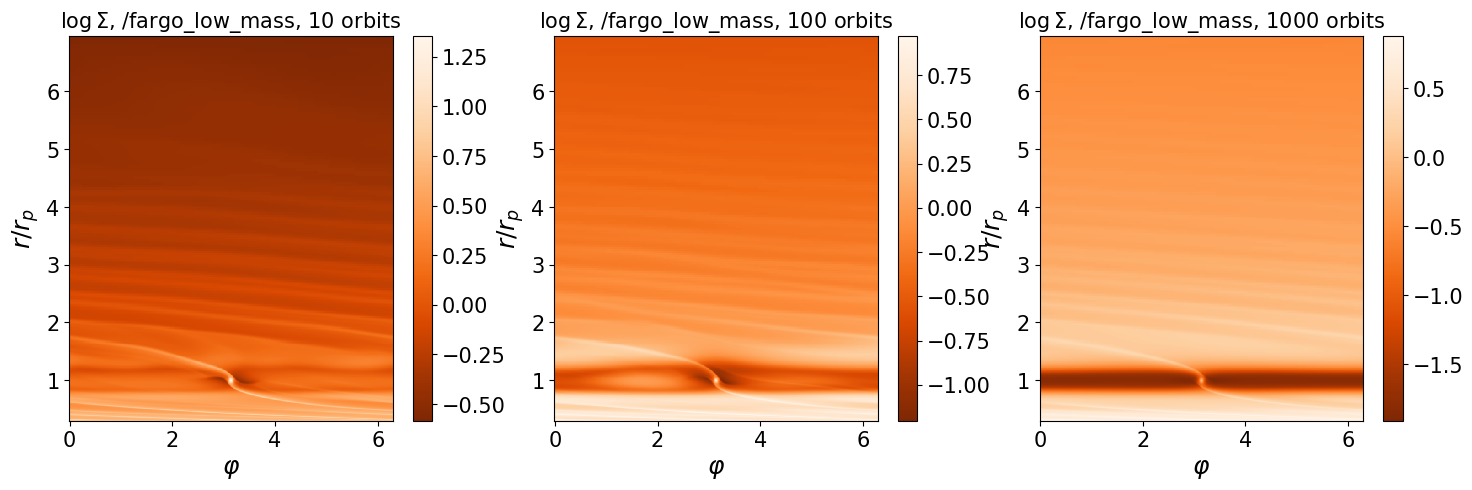

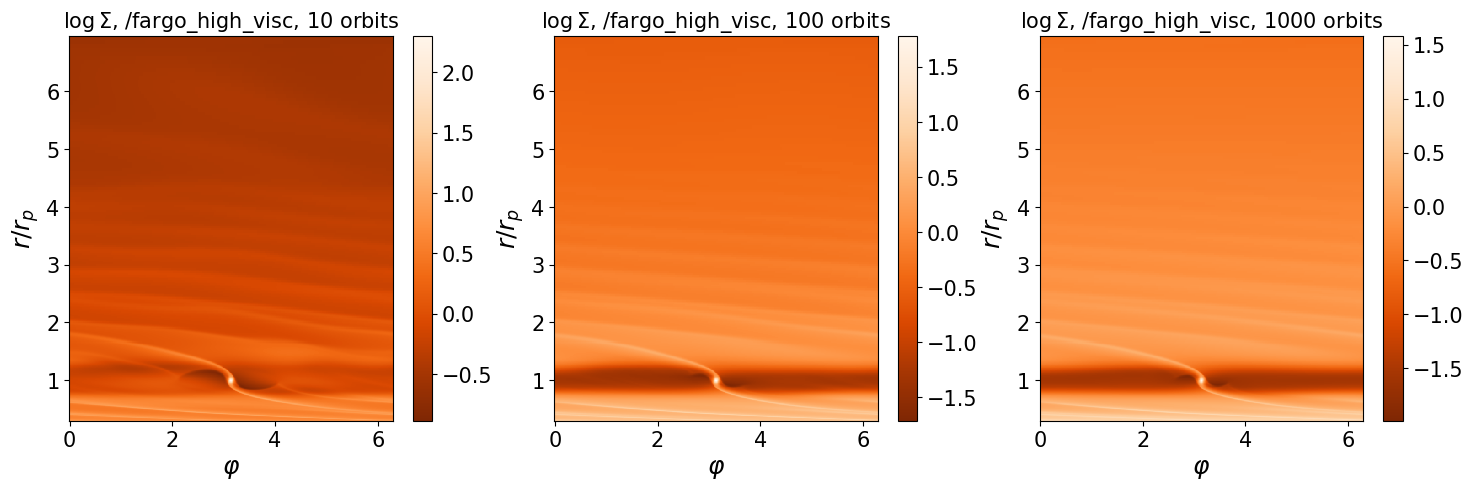

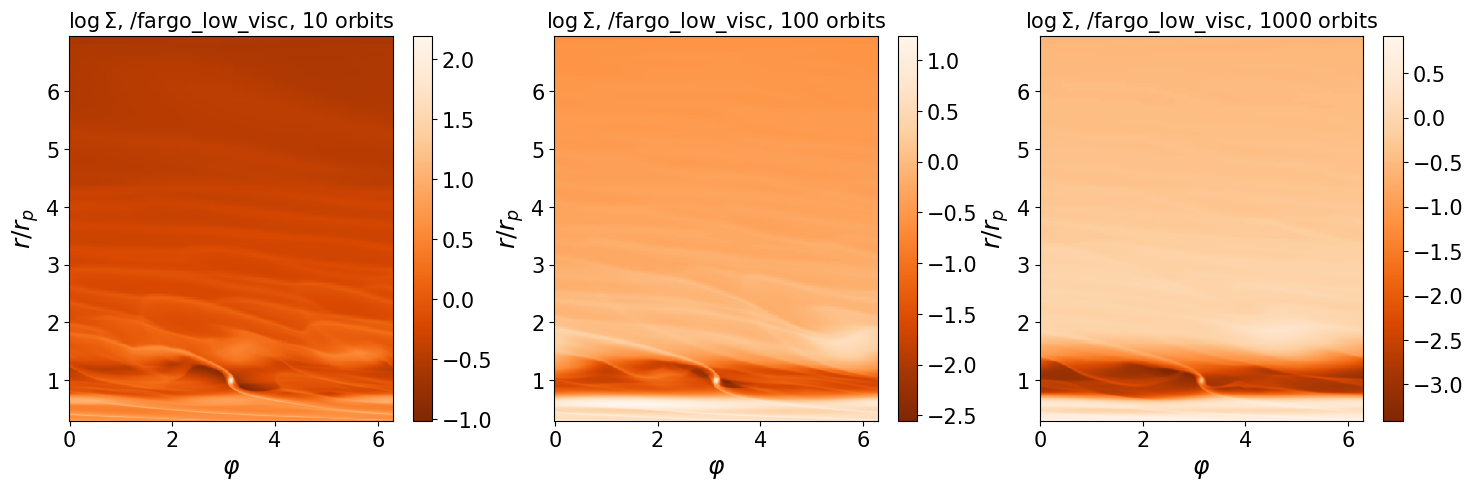

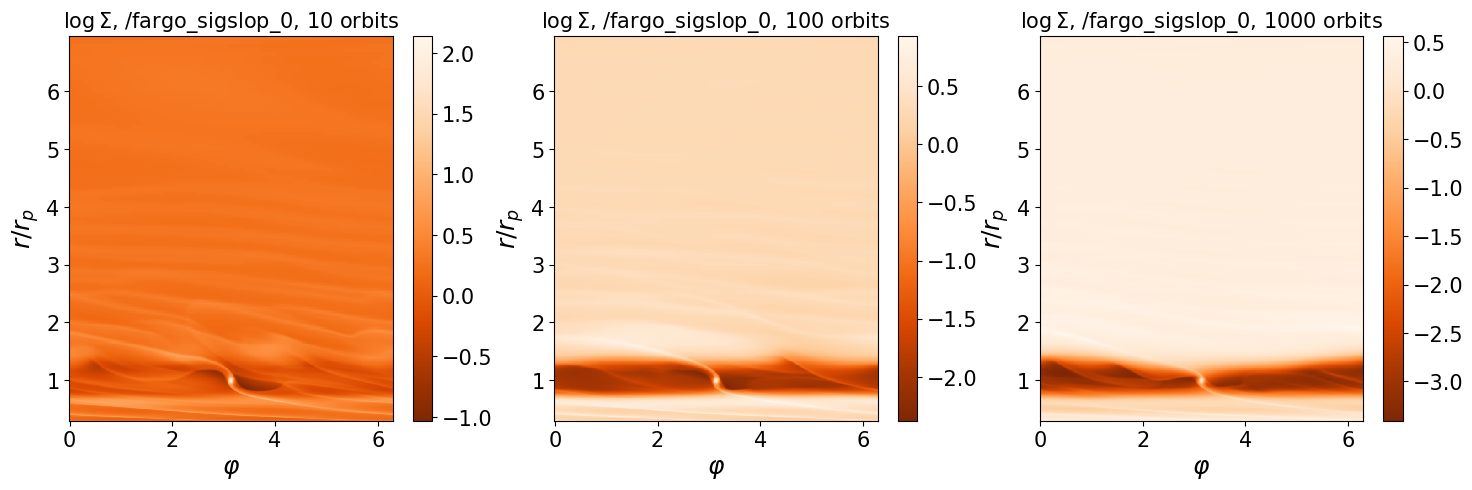

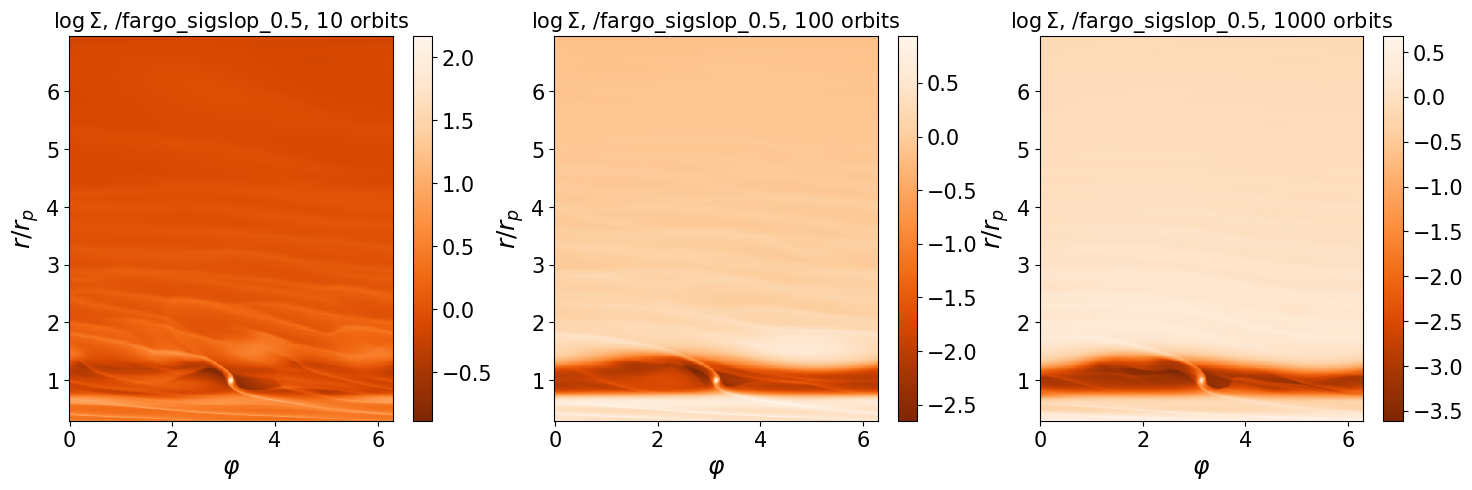

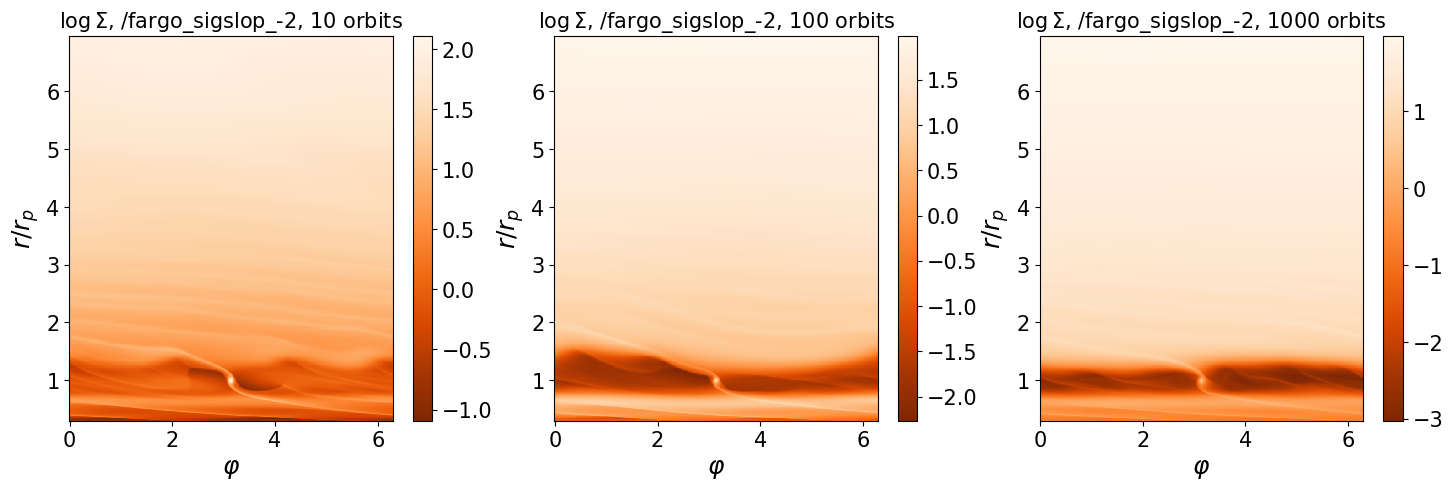

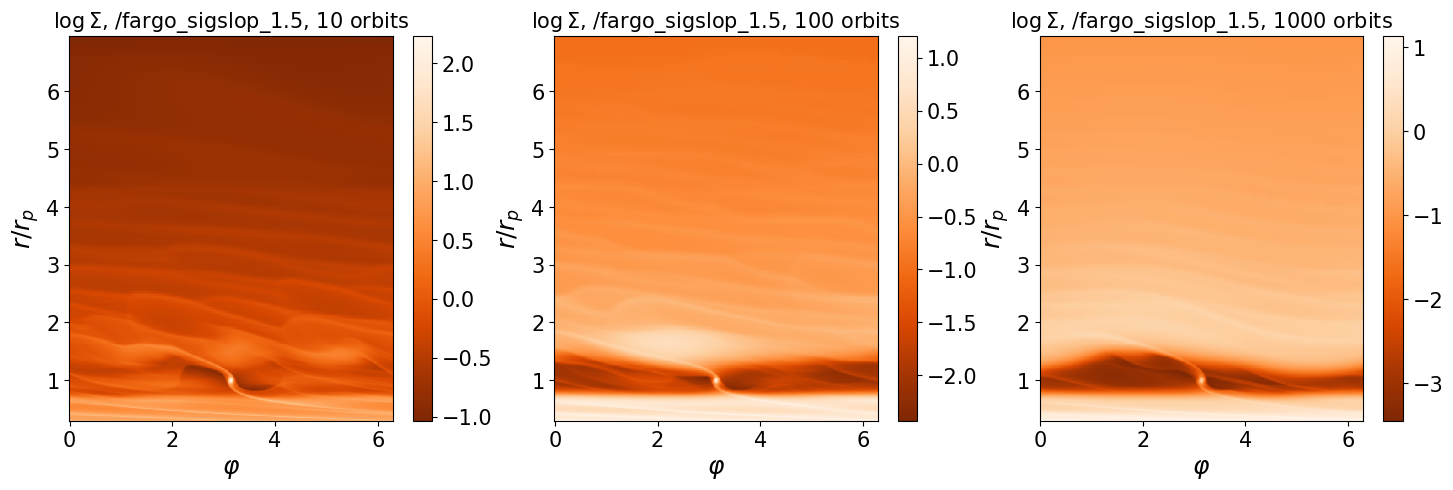

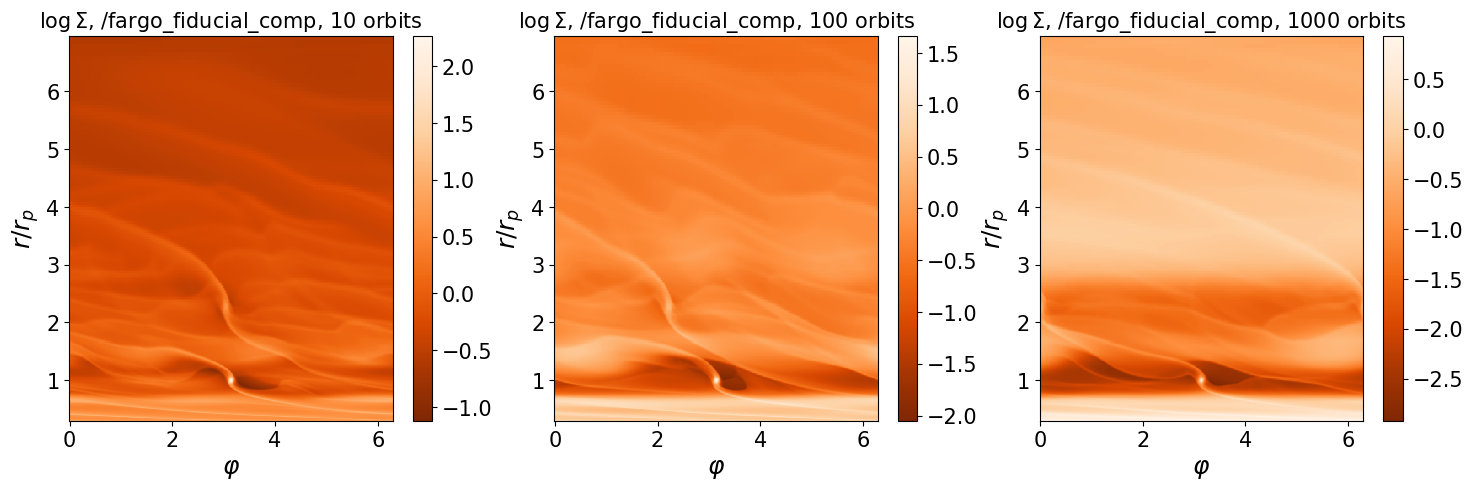

In [19]:

%matplotlib inline
r_min = 0.3
r_max = 7


for i in range(len(paths)):
    plt.figure(figsize=(6*len(frames),5))
    path = paths[i]
    for it,frame in enumerate(frames):
        if frame==0:
            continue
        plt.subplot(1,len(frames),it+1)
        plt.pcolormesh(PHI, R, np.log10(rho_cube[i][it]),cmap=cm.Oranges_r, shading='auto')
        plt.xlabel("$\\varphi$")
        plt.ylabel("$r/r_p$")
        plt.title(f"$\\log \\Sigma$, {path[43:-5]}, {(frame)*10} orbits")
        plt.colorbar()

## different masses

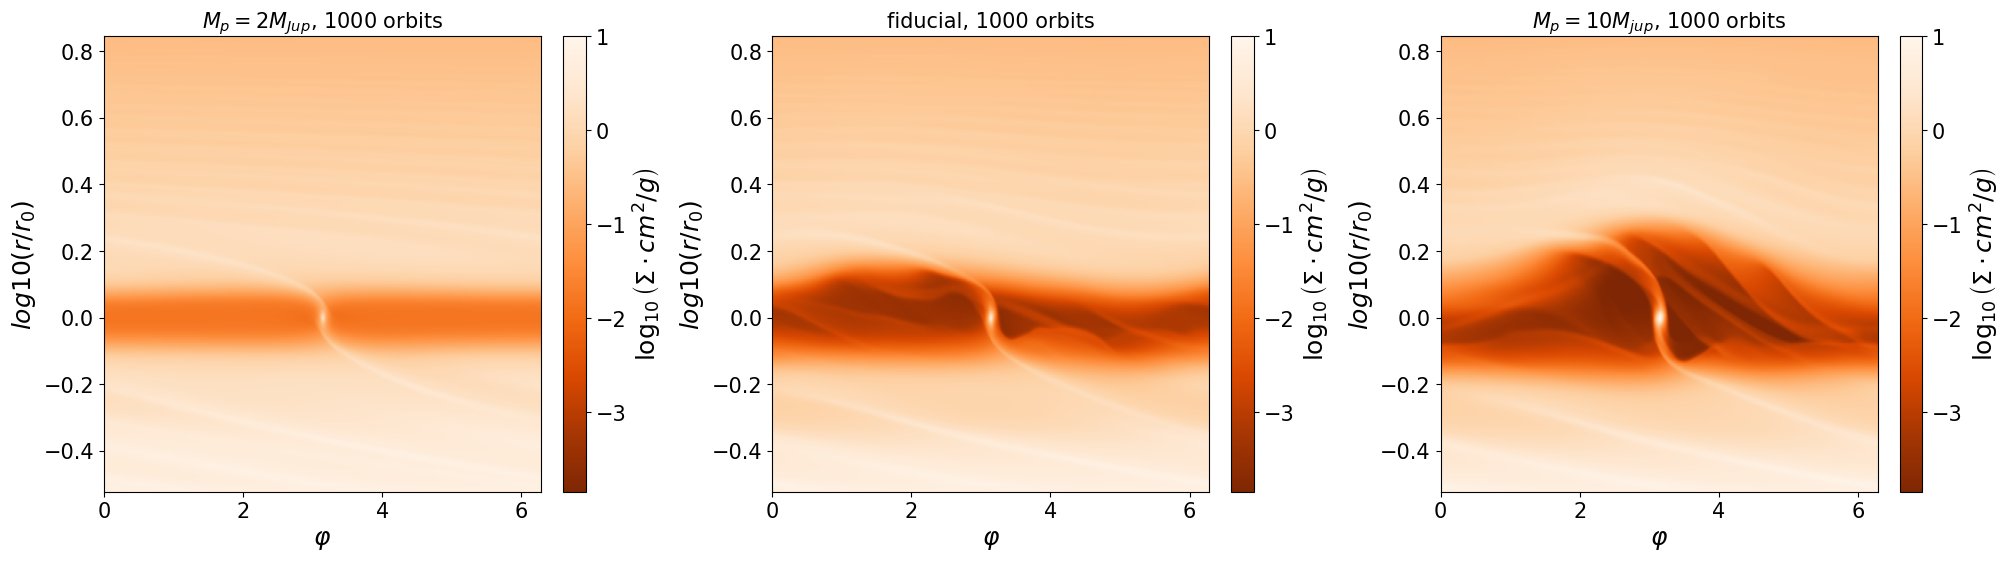

In [49]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_mass=[2,0,1]
frame = frames[-1]

plt.figure(figsize=(20,5.5), constrained_layout=True)

for it,i in enumerate(index_for_mass):
    path = paths[i]
    title = titles[i]
    
        
    plt.subplot(1,3,it+1)
    plt.imshow(np.log10(rho_cube[i][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
    plt.title(f"{title}, {(frame)*10} orbits")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar(label="$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$")
plt.savefig("img/different_masses_fargo.PNG", bbox_inches="tight")

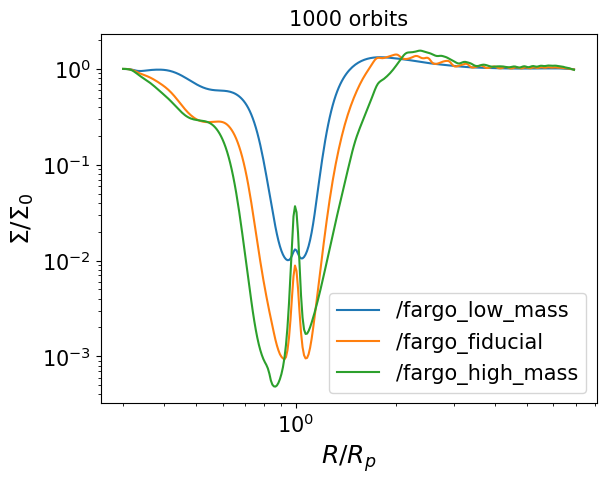

In [21]:
rho_mean = np.mean(rho_cube, axis=3)


for i in index_for_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

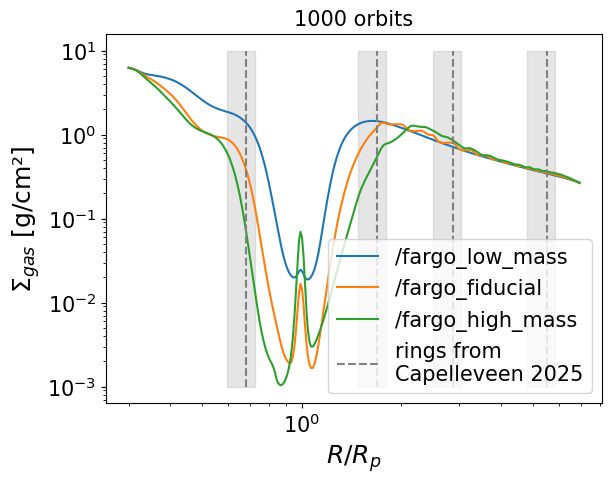

In [22]:
rho_mean = np.mean(rho_cube, axis=3)
for i in index_for_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1], label=f"{path[43:-5]}")

r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

gap = 69/r_p
gap_width = 59/2/r_p

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")
        

#plt.plot([gap,gap,],[1e-3,1e1], color="gray",label="gap from \nCapelleveen 2025")
#plt.fill_between([gap-gap_width,gap+gap_width], 1e-3,1e1, alpha=0.2)

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{gas}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="lower right")
plt.savefig("img/masses_densities.png")

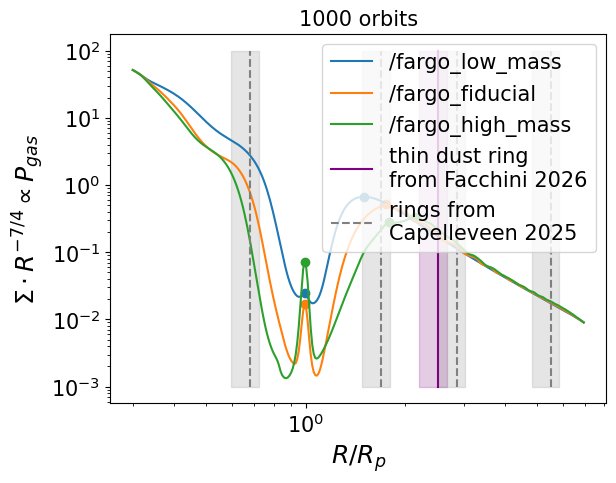

In [23]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

for i in index_for_mass:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("img/masses_dust_traps.png")

## different viscosities

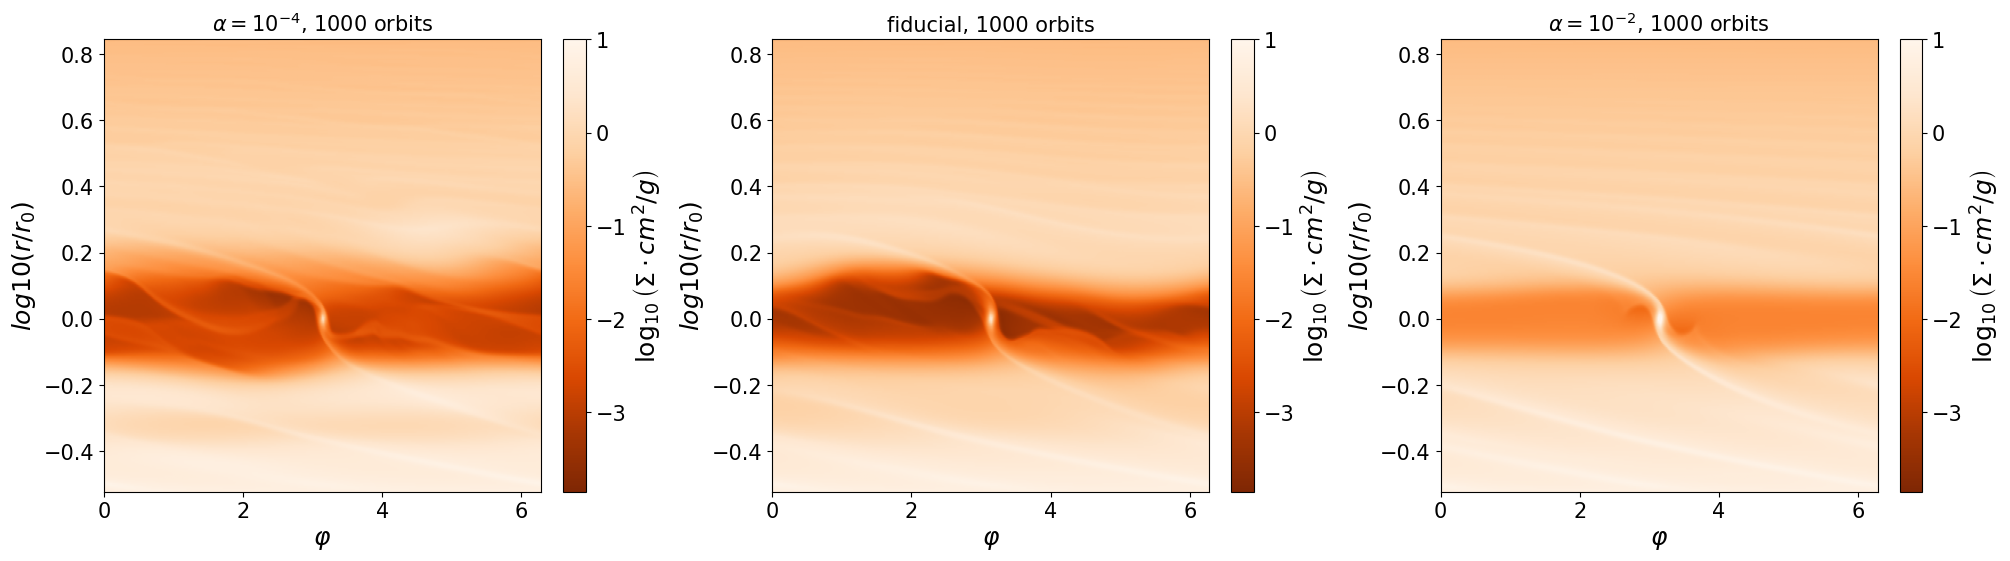

In [50]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_visc=[4,0,3]


plt.figure(figsize=(20,5.5), constrained_layout = True)

for it,i in enumerate(index_for_visc):
    title = titles[i]
    
        
    plt.subplot(1,3,it+1)
    plt.imshow(np.log10(rho_cube[i][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
    plt.title(f"{title}, {(frame)*10} orbits")
    plt.colorbar(label="$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")

plt.savefig("img/different_viscs_fargo.PNG", bbox_inches="tight")

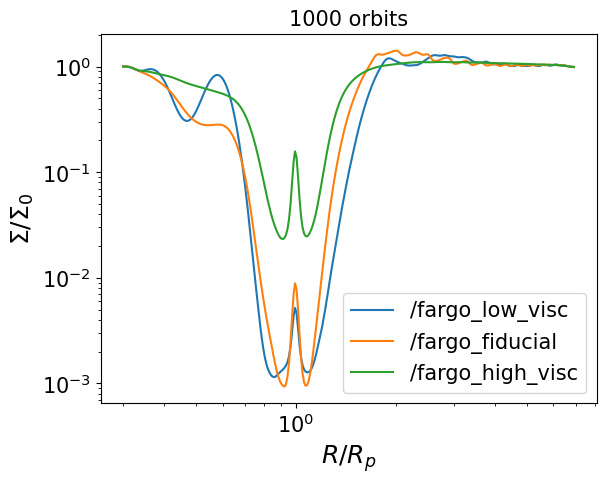

In [25]:
rho_mean = np.mean(rho_cube, axis=3)


for i in index_for_visc:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}")

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()


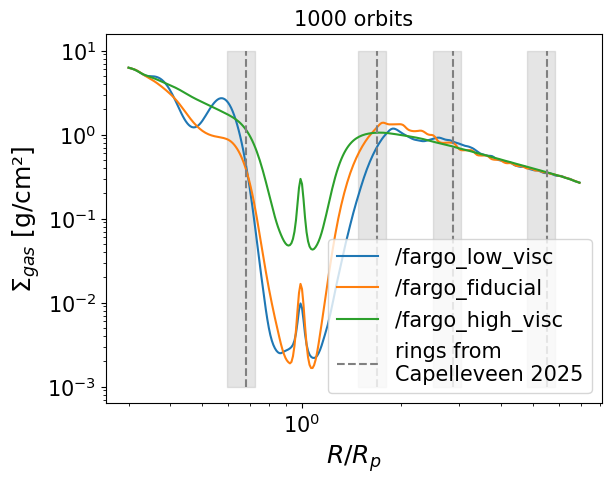

In [26]:
rho_mean = np.mean(rho_cube, axis=3)
for i in index_for_visc:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1], label=f"{path[43:-5]}")


r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

gap = 69/r_p
gap_width = 59/2/r_p

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{gas}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="lower right")
plt.savefig("img/viscs_densities.png")

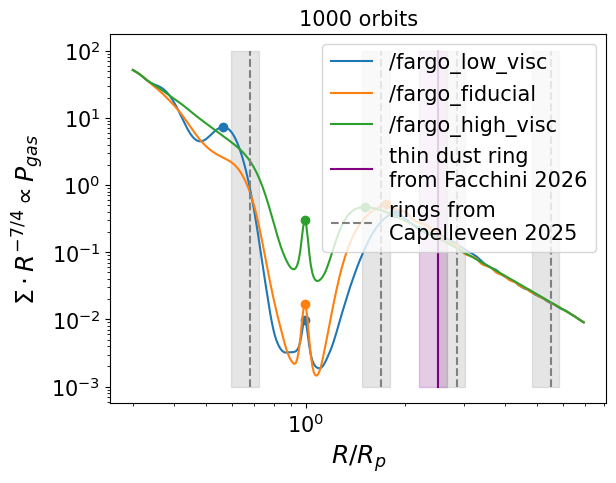

In [27]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)
rings_from_capelleveen = np.array([316, 164, 97, 39])/57 # in r/r_p

for i in index_for_visc:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])


first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("img/viscs_dust_traps.png")

## different sigma slopes

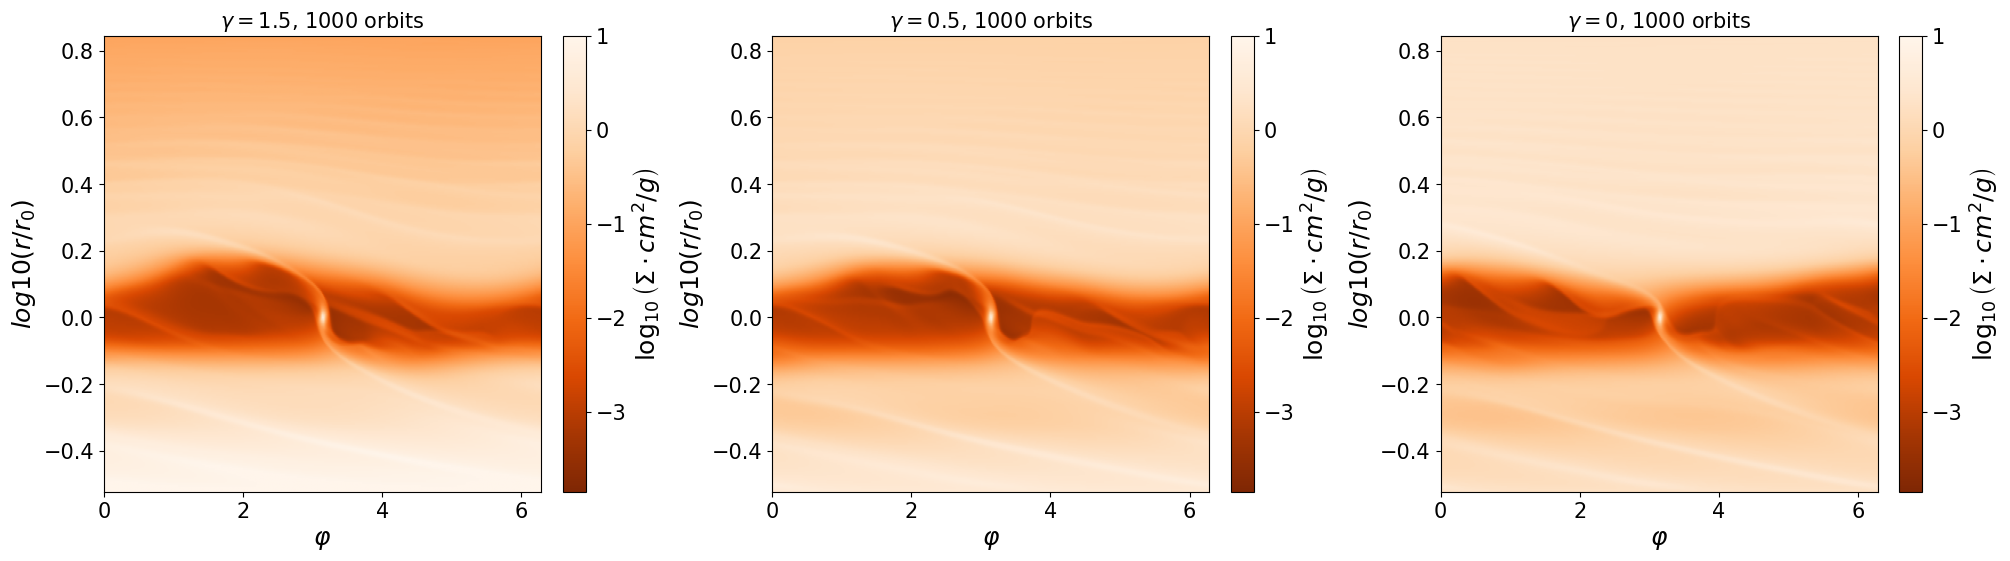

In [51]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_sigslop = [8,6,5]#,7]


plt.figure(figsize=(20,5.5), constrained_layout=True)

for it,i in enumerate(index_for_sigslop):
    title = titles[i]
    
        
    plt.subplot(1,3,it+1)
    plt.imshow(np.log10(rho_cube[i][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
    plt.title(f"{title}, {(frame)*10} orbits")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar(label="$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$")

plt.savefig("img/different_sigslop_fargo.PNG", bbox_inches="tight")

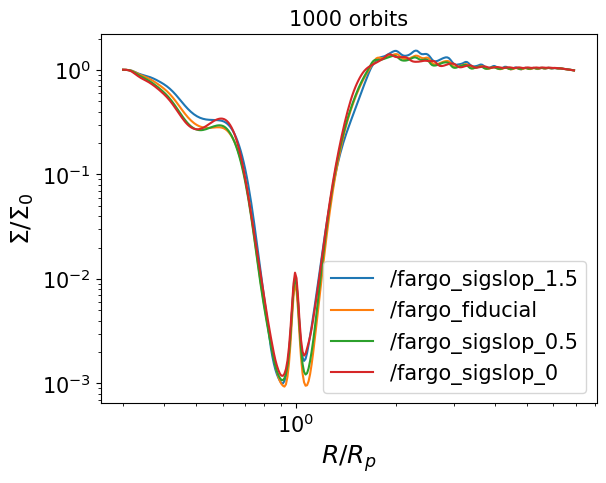

In [29]:
rho_mean = np.mean(rho_cube, axis=3)
index_for_sigslop = [8,0,6,5]#,7]

for i in index_for_sigslop:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}")

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

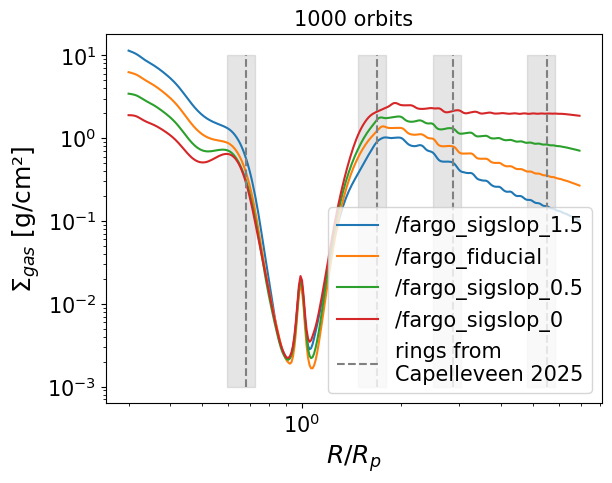

In [30]:
rho_mean = np.mean(rho_cube, axis=3)
for i in index_for_sigslop:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1], label=f"{path[43:-5]}")
    #plt.scatter(r_list,rho_mean[i][0], s=1,label=f"{path[43:-5]}")

r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

gap = 69/r_p
gap_width = 59/2/r_p

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{gas}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()
plt.savefig("img/sigslop_densities.png")

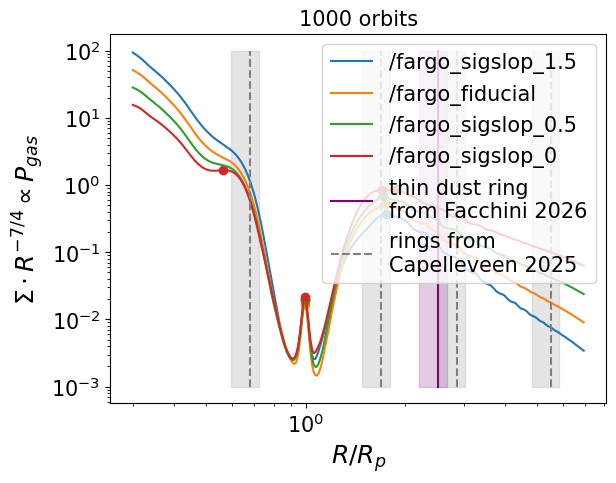

In [31]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

for i in index_for_sigslop[:]:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])


first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("img/sigslop_dust_traps.png")

In [32]:
## time for one orbit

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au
G = 6.6741e-11 #m³⋅kg⁻¹⋅s⁻²
T = 2*np.pi * np.sqrt(r0**3/G/mstar)

print(f"Time for one orbit: {T/60/60/25/365/1e3} kyrs")
print(f"Time for 1000 orbits: {T/60/60/25/365/1e3} Myrs")

Time for one orbit: 12.578491746169425 kyrs
Time for 1000 orbits: 12.578491746169425 Myrs


In [33]:
## viscous time scale
alpha = 1e-3
t_visc = r0/alpha/1.04e3*20

print(f"Viscous time scale: {t_visc/60/60/25/365/1e3} kyrs")
# seems way too big.

Viscous time scale: 499185.4583772392 kyrs


# Evolution

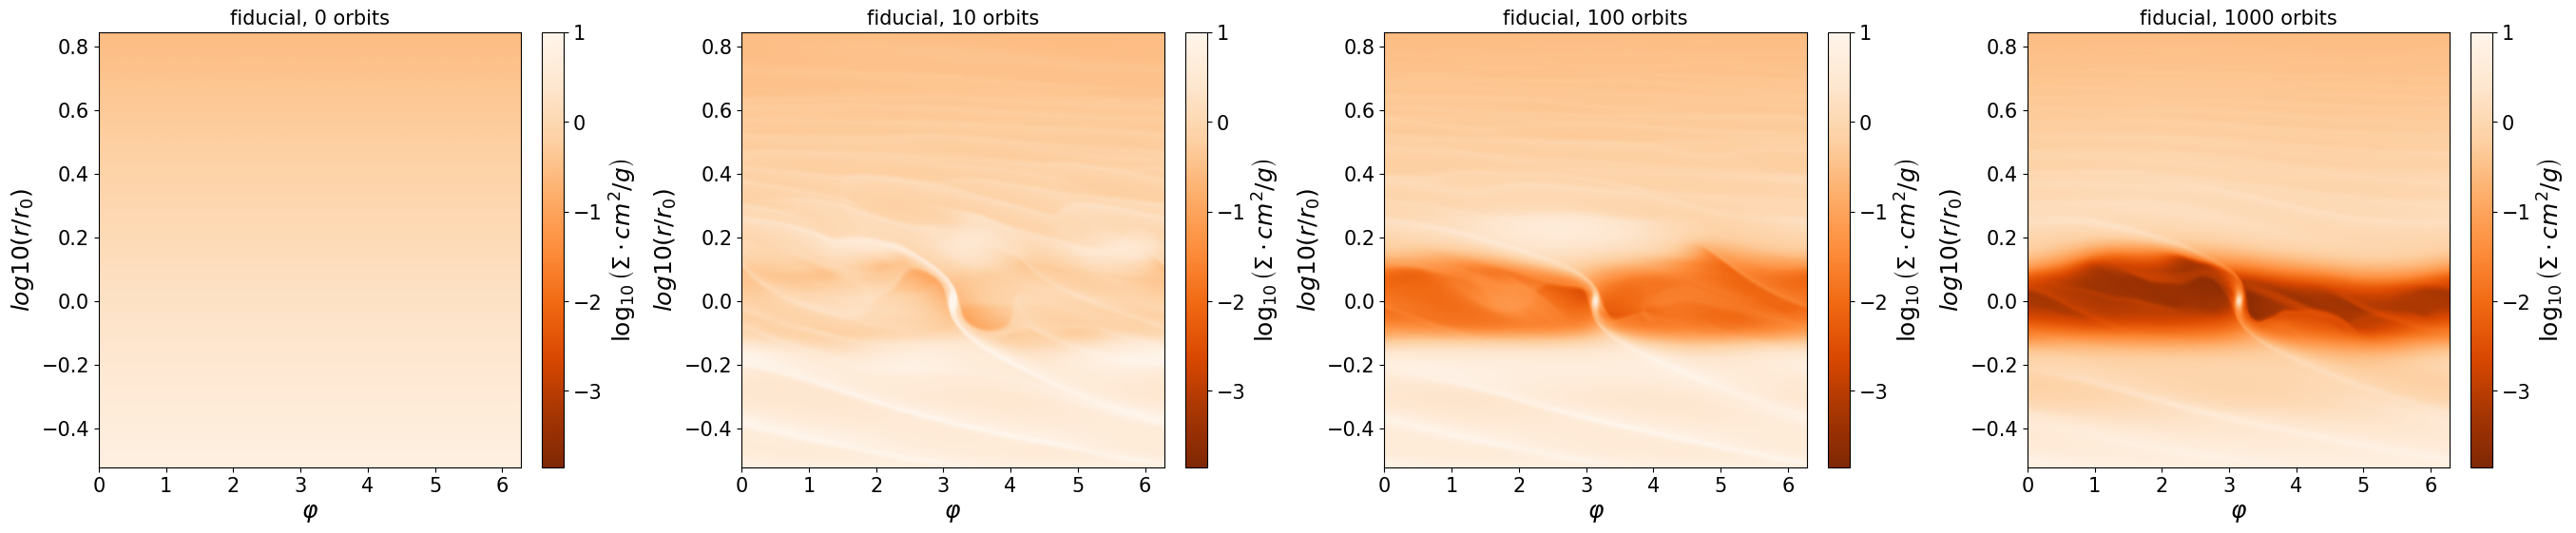

In [48]:
%matplotlib inline
r_min = 0.3
r_max = 7
i = 0
plt.figure(figsize=(27,5.5), constrained_layout=True)

for it,frame in enumerate(frames):
    path = paths[i]
    title = titles[i]
    
        
    plt.subplot(1,4,it+1)
    plt.imshow(np.log10(rho_cube[i][it]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
    plt.title(f"{title}, {(frame)*10} orbits")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar(label="$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$")
plt.savefig("img/fargo_fiducial_gap_opening.png", bbox_inches="tight")

In [39]:
frames

0